# DTSA 5009 Final Project
For my final project, I choose to analyze and model home sales prices in Ames, Iowa. I received this dataset from Kaggle.com and the link is here https://www.kaggle.com/competitions/home-data-for-ml-course/overview.
Here is some more information about the dataset from Kaggle: 
Ask a home buyer to describe their dream house, and they probably won't begin with the height of the basement ceiling or the proximity to an east-west railroad. But this dataset proves that much more influences price negotiations than the number of bedrooms or a white-picket fence. There are 79 explanatory variables describing (almost) every aspect of residential homes in Ames, Iowa. Here the key groups of the variables in the dataset:
Key Groups:

Identifiers: Id

<b>Structural Attributes</b>: MSSubClass, OverallQual/Cond, YearBuilt, YearRemodAdd

<b>Lot & Land Features</b>: LotFrontage, LotArea, LotShape, LandContour, LandSlope

<b>Exterior & Basement</b>: Exterior1st/2nd, MasVnrType/Area, BsmtQual/Cond/Exposure, TotalBsmtSF

<b>Living Areas & Rooms</b>: 1stFlrSF, 2ndFlrSF, GrLivArea, bathroom/bedroom counts

<b>Garage & Miscellaneous</b>: GarageType/Area/Cars/Cond, PoolQC, Fence, MiscFeature/Val

<b>Sale Info</b>: MoSold, YrSold, SaleType, SaleCondition, and the target SalePrice



### ML problem at hand
We want to use the training data from Kaggle to train a ML model so that it can predict home sale prices given a test dataset.

## EDA

#Import libraries

In [1]:
import pandas as pd
import numpy as np

#load downloaded data from kaggle that can be found in github repo

In [5]:
url = 'https://github.com/dnmorgan/MSDS/blob/DTSA5009/train.csv?raw=true'
df = pd.read_csv(url,index_col=0)
print(df.head(5))


    MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
Id                                                                    
1           60       RL         65.0     8450   Pave   NaN      Reg   
2           20       RL         80.0     9600   Pave   NaN      Reg   
3           60       RL         68.0    11250   Pave   NaN      IR1   
4           70       RL         60.0     9550   Pave   NaN      IR1   
5           60       RL         84.0    14260   Pave   NaN      IR1   

   LandContour Utilities LotConfig  ... PoolArea PoolQC Fence MiscFeature  \
Id                                  ...                                     
1          Lvl    AllPub    Inside  ...        0    NaN   NaN         NaN   
2          Lvl    AllPub       FR2  ...        0    NaN   NaN         NaN   
3          Lvl    AllPub    Inside  ...        0    NaN   NaN         NaN   
4          Lvl    AllPub    Corner  ...        0    NaN   NaN         NaN   
5          Lvl    AllPub       FR2  ... 

In [6]:
# 1. Dataset Components
print("=== Dataset Components ===")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("\nData types breakdown:")
print(df.dtypes.value_counts())

print("\nSample of columns by type:")
print("Numeric:", df.select_dtypes(include=[np.number]).columns.tolist()[:10], "...")
print("Categorical:", df.select_dtypes(include=['object']).columns.tolist()[:10], "...")


=== Dataset Components ===
Number of rows: 1460
Number of columns: 80

Data types breakdown:
object     43
int64      34
float64     3
Name: count, dtype: int64

Sample of columns by type:
Numeric: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2'] ...
Categorical: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1'] ...


#2. Missing Values Summary

In [7]:
print("\n=== Missing Values Summary ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)
print(missing_summary.head(20))


=== Missing Values Summary ===
              missing_count  missing_pct
PoolQC                 1453        99.52
MiscFeature            1406        96.30
Alley                  1369        93.77
Fence                  1179        80.75
MasVnrType              872        59.73
FireplaceQu             690        47.26
LotFrontage             259        17.74
GarageYrBlt              81         5.55
GarageCond               81         5.55
GarageType               81         5.55
GarageFinish             81         5.55
GarageQual               81         5.55
BsmtExposure             38         2.60
BsmtFinType2             38         2.60
BsmtCond                 37         2.53
BsmtQual                 37         2.53
BsmtFinType1             37         2.53
MasVnrArea                8         0.55
Electrical                1         0.07
MSSubClass                0         0.00


#3. Identify Potential Columns to Drop 

In [8]:
# e.g. drop columns with > 50% missing
drop_thresh = 50.0
to_drop = missing_summary[missing_summary['missing_pct'] > drop_thresh].index.tolist()
print(f"\nColumns with >{drop_thresh}% missing (to consider dropping):")
print(to_drop)


Columns with >50.0% missing (to consider dropping):
['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']


#4. Imputation Strategy

In [11]:
# Impute LotFrontage by median within each Neighborhood
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'] \
                                     .transform(lambda x: x.fillna(x.median()))

# Fill other categorical gaps with "None"
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna('None')

print("\nAfter imputation, missing values remaining:")
print(df.isnull().sum().loc[lambda x: x > 0])



After imputation, missing values remaining:
MasVnrArea      8
GarageYrBlt    81
dtype: int64


#5. Look at Correlations

In [13]:
#Correlation with SalePrice
print("\n=== Top 10 Features Correlated with SalePrice ===")
numeric = df.select_dtypes(include=[np.number])
corr = numeric.corr()['SalePrice'].abs().sort_values(ascending=False).drop('SalePrice')
print(corr.head(10))


=== Top 10 Features Correlated with SalePrice ===
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


#6 Actually droping columns
Since none of the variables listed with over 50% missing are in the top ten features correlated with saleprice above, we
will now drop them

In [15]:
df = df.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType'])

#7 Determining variables to transform

Matplotlib is building the font cache; this may take a moment.


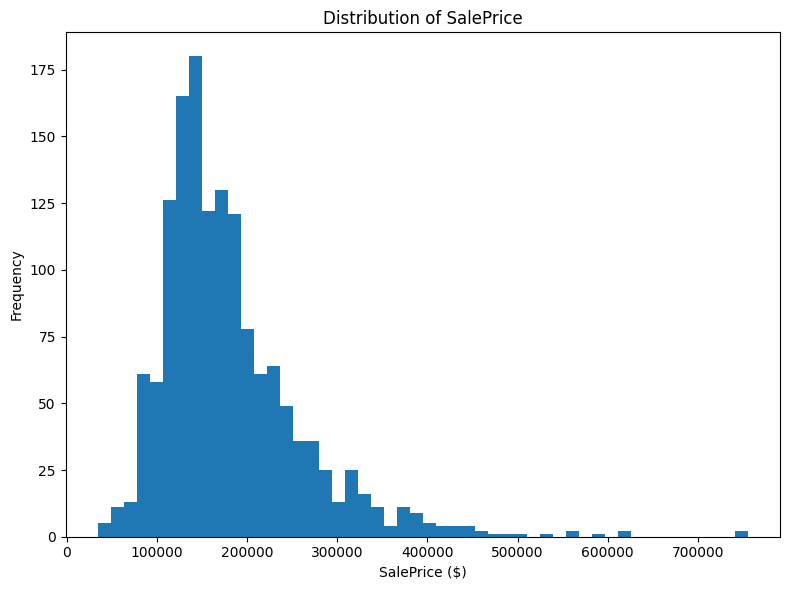

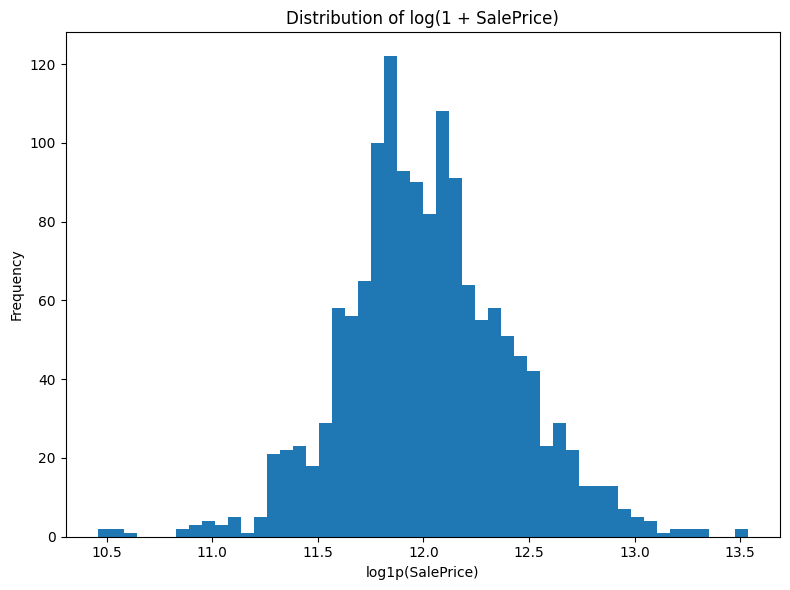

In [36]:
#!pip install matplotlib
import matplotlib.pyplot as plt
# Histogram of SalePrice
plt.figure(figsize=(8, 6))
plt.hist(df['SalePrice'], bins=50)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice ($)')
plt.ylabel('Frequency')
plt.tight_layout()

# Histogram of log1p(SalePrice)
plt.figure(figsize=(8, 6))
plt.hist(np.log1p(df['SalePrice']), bins=50)
plt.title('Distribution of log(1 + SalePrice)')
plt.xlabel('log1p(SalePrice)')
plt.ylabel('Frequency')
plt.tight_layout()

plt.show()


We see that SalePrice is highly right-skewed. Whereas Log1p(SalePrice) is nearly symmetric.

Given this information from the histogram, we will model the target on the log scale (y = log1p(SalePrice)) to stabilize variance and improve linear-model assumptions.

# Running the models

In [22]:
#load proper libraries and funcitons from 
#!pip install scikit-learn
#import sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [27]:
X = df.drop(['SalePrice'], axis=1)
y = np.log1p(df['SalePrice'])
#print(df.columns)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Identify column types
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Preprocessing pipelines

# imputer fills any missing numeric values by replacing them with the median of that column.
#StandardScaler centers each numeric column to mean = 0 and scales to unit variance

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


#imputer replaces missing categorical entries with the string "None".
#onehot converts each categorical column into a set of binary “one-hot” indicator columns (one per category). 

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

#The following tells scikit-learn:
#Apply the numeric_pipeline to just the columns in numeric_cols.
#Apply the categorical_pipeline to just the columns in categorical_cols.
#The result is a single preprocessed feature matrix (all numeric) ready for modeling.

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

# 1) Log-Linear OLS Pipeline
ols_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LinearRegression())
])

# 2) Random Forest Pipeline
rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100, random_state=42
    ))
])

# Fit both models
ols_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MSSubClass', 'LotFrontage',
                                                   'LotArea', 'OverallQual',
                                                   'OverallCond', 'YearBuilt',
                                                   'YearRemodAdd', 'MasVnrArea',
                                                   'BsmtFinSF1', 'BsmtFinSF2',
                                                   'BsmtUnfSF', 'TotalBsmtSF',
                                                   '1stFlrSF', '2ndFlrSF',
                                                   'LowQualFinSF', '...
                                                   'LandSlope', 'Neighborhood',
                                                   'Condition1', 'Condition2',
                                                   'BldgType', 'HouseStyle',
                                                   'RoofStyle', 'RoofMatl',
                                                   'Exterior1st', 'Exterior2nd',
                                                   'ExterQual', 'ExterCond',
                                                   'Foundation', 'BsmtQual',
                                                   'BsmtCond', 'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'Heating',
                                                   'HeatingQC', 'CentralAir',
                                                   'Electrical', 'KitchenQual',
                                                   'Functional', ...])])),
                ('model', RandomForestRegressor(random_state=42))])

In [28]:
# Evaluate on test set
for name, pipe in [('OLS', ols_pipeline), ('Random Forest', rf_pipeline)]:
    preds = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"{name} Root Mean Squared Error (log1p target): {rmse:.4f}")

OLS RMSE (log1p target): 0.1299
Random Forest RMSE (log1p target): 0.1450


# Model Interpretation

The OLS (log-linear) model achieved a lower RMSE (0.1299) than the Random Forest (0.1450), so on this split it’s fitting the log-transformed target more closely.

The log-linear OLS model’s predictions on the test set are, on average, about 14% off from the true SalePrice.

The Random Forest is about 16% off.

The lower RMSE of the OLS tells us it generalizes slightly better here. Possibly because the relationship is fairly linear once the log-transform SalePrice and do basic imputation encoding.

# Hyperparameter optimization

I will use RandomizedSearchCV to tune five key Random Forest hyperparameters:

n_estimators (number of trees)

max_depth (tree depth)

max_features (features tried at each split)

min_samples_split

min_samples_leaf

It runs 20 random combinations via 5-fold CV, reports the best settings, and then computes the test-set RMSE on the log-transformed target.

In [32]:
from sklearn.model_selection import RandomizedSearchCV

# Random Forest pipeline
rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Hyperparameter distributions
param_dist = {
    'model__n_estimators': [100, 200, 500],
    'model__max_depth': [None, 10, 20, 30],
    'model__max_features': ['sqrt', 'log2', None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

# Randomized search with error_score='raise' for easier debugging
rs = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=2,
    n_jobs=-1,
    random_state=42,
    error_score='raise'
)

# Fit search
rs.fit(X_train, y_train)

# Best parameters and evaluation
print("Best parameters found:", rs.best_params_)
best_rf = rs.best_estimator_
y_pred = best_rf.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Test RMSE (log1p target): {rmse_test:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters found: {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 20}
Test RMSE (log1p target): 0.1445
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=4, model__min_samples_split=10, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=500; total time=   1.0s
[CV] END model__max_depth=20, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=100; total time=   0.3s
[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=100; total time=   0.2s
[CV] END model__max_depth=10, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=2, model__

### Conclusion

On the hold-out set, the tuned forest’s predictions of log1p(SalePrice) are off by about 0.1445 in root-mean-squared‐error. Which means in dollars that the tuned RF is about 15-16% off, on average, when predicting sale prices. This model still trains the OLS of only ~14% error. The OLS (log-linear) model achieved a lower root mean squared error (RMSE) (0.1299) than the Random Forest (0.1450) and tuned Random Forest (0.1445).